In [20]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


df = pd.read_csv('train (1).csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [21]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [22]:
X = df.drop('Survived',axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

X_train['Age_imputer'] = X_train['Age']
X_test['Age_imputer'] = X_test['Age']

X_train['Age_imputer'][X_train['Age_imputer'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum(), random_state=42).values
X_test['Age_imputer'][X_test['Age_imputer'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum(), random_state=42).values


C:\Users\MY PC\AppData\Local\Temp\ipykernel_10656\2263024056.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  X_train['Age_imputer'][X_train['Age_imputer'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum(), random_state=42).values
C:\Users\MY PC\AppData\Local\Temp\ipykernel_10656\2263024056.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the origina

C:\Users\MY PC\AppData\Local\Temp\ipykernel_10656\1930640616.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label='Original',hist=False)
C:\Users\MY PC\AppData\Local\Temp\ipykernel_10656\1930640616.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[

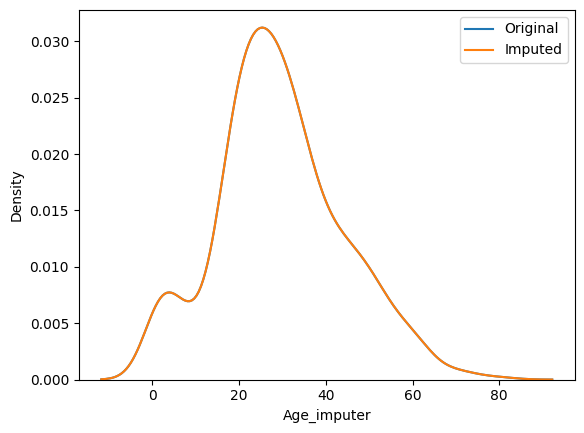

In [24]:
sns.distplot(X_train['Age'],label='Original',hist=False)
sns.distplot(X_train['Age_imputer'],label='Imputed',hist=False)
plt.legend()
plt.show()

In [25]:
print('Original Age variable has null values: ',X_train['Age'].var())
print('Variable with imputed values has null values: ',X_train['Age_imputer'].var())

Original Age variable has null values:  210.2517072477435
Variable with imputed values has null values:  210.2517072477435


In [26]:
X_train[['Fare','Age','Age_imputer']].cov()

,Fare,Age,Age_imputer
Fare,2700.831981,71.580633,71.580633
Age,71.580633,210.251707,210.251707
Age_imputer,71.580633,210.251707,210.251707


<Axes: >

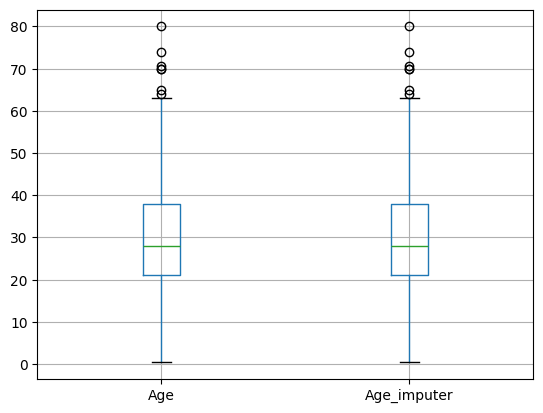

In [27]:
X_train[['Age','Age_imputer']].boxplot()

In [28]:
sample_value = X_train['Age'].dropna().sample(10, random_state=42)


In [31]:
df2 = pd.read_csv('house-train (1).csv',usecols=['GarageQual','FireplaceQu','SalePrice'])
df2.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [32]:
df2.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [33]:
X = df2
y = df2['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

X_train['GarageQual_imputer'] = X_train['GarageQual']
X_test['GarageQual_imputer'] = X_test['GarageQual']

X_train['FireplaceQu_imputer'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputer'] = X_test['FireplaceQu']



In [35]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputer,FireplaceQu_imputer
1236,NaN,TA,175500,TA,NaN
1406,NaN,TA,133000,TA,NaN
890,Po,TA,122900,TA,Po
108,NaN,NaN,115000,NaN,NaN
997,TA,TA,185000,TA,TA


In [36]:
X_train['GarageQual_imputer'][X_train['GarageQual_imputer'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum(), random_state=42).values
X_test['GarageQual_imputer'][X_test['GarageQual_imputer'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum(), random_state=42).values

X_train['FireplaceQu_imputer'][X_train['FireplaceQu_imputer'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum(), random_state=42).values
X_test['FireplaceQu_imputer'][X_test['FireplaceQu_imputer'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum(), random_state=42).values

C:\Users\MY PC\AppData\Local\Temp\ipykernel_10656\3404810355.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  X_train['GarageQual_imputer'][X_train['GarageQual_imputer'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum(), random_state=42).values
C:\Users\MY PC\AppData\Local\Temp\ipykernel_10656\3404810355.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never

In [43]:
temp1 = pd.concat(
    [
        X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
        X_train['GarageQual_imputer'].value_counts() / len(X_train)
    ], axis=1)

temp1.columns = ['Original', 'Imputed']
temp1


temp2 = pd.concat(
    [
        X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
        X_train['FireplaceQu_imputer'].value_counts() / len(X_train)
    ], axis=1)
temp2.columns = ['Original', 'Imputed']
temp2

,Original,Imputed
Gd,0.491143,0.261130
TA,0.405797,0.215753
Fa,0.043478,0.023116
Ex,0.033816,0.017979
Po,0.025765,0.013699


C:\Users\MY PC\AppData\Local\Temp\ipykernel_10656\307671602.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'], label=category, hist=False)
C:\Users\MY PC\AppData\Local\Temp\ipykernel_10656\307671602.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457a

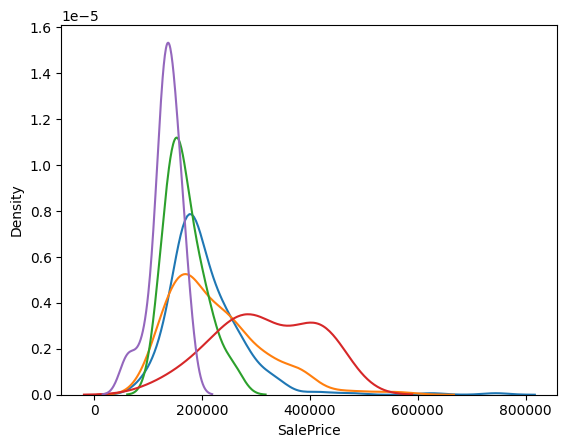

In [46]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'], label=category, hist=False)

plt.show()

C:\Users\MY PC\AppData\Local\Temp\ipykernel_10656\2161841168.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu_imputer'] == category]['SalePrice'], label=category, hist=False)
C:\Users\MY PC\AppData\Local\Temp\ipykernel_10656\2161841168.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147

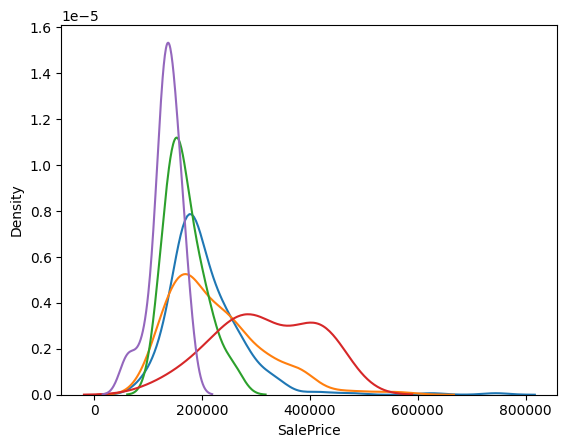

In [47]:
for category in X_train['FireplaceQu_imputer'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu_imputer'] == category]['SalePrice'], label=category, hist=False)

plt.show()